In [1]:
from dataclasses import dataclass

@dataclass
class CFG:
    CHEXPERT_ROOT: str = r"C:\Users\Leong Yao Cheng\Documents\thesis dataset\Chest\CheXpert\CheXpert-v1.0-small"
    TRAIN_CSV: str = "train.csv"
    VALID_CSV: str = "valid.csv"
    OUTDIR: str = "./ldm_chexpert_out"
    LOG_EVERY: int = 100
    SAVE_EVERY: int = 5
    IMAGE_SIZE: int = 192
    BATCH: int = 6
    NUM_WORKERS: int = 0
    STRICT_NORMALS: bool = True
    LATENT_CH: int = 72
    VAE_LR: float = 2e-4
    VAE_EPOCHS: int = 100
    VAE_BETA_KL: float = 1e-4
    VAE_BETA_KL_MAX: float = 1e-4
    TIMESTEPS: int = 1000
    BETA_START: float = 1e-4
    BETA_END: float = 5e-3
    LDM_LR: float = 3e-5
    LDM_EPOCHS: int = 150
    UNET_BASE: int = 128
    AMP: bool = True
    DDIM_STEPS: int = 150
    SAMPLE_N: int = 4

cfg = CFG()
print(cfg)
    

CFG(CHEXPERT_ROOT='C:\\Users\\Leong Yao Cheng\\Documents\\thesis dataset\\Chest\\CheXpert\\CheXpert-v1.0-small', TRAIN_CSV='train.csv', VALID_CSV='valid.csv', OUTDIR='./ldm_chexpert_out', LOG_EVERY=100, SAVE_EVERY=5, IMAGE_SIZE=192, BATCH=6, NUM_WORKERS=0, STRICT_NORMALS=True, LATENT_CH=72, VAE_LR=0.0002, VAE_EPOCHS=100, VAE_BETA_KL=0.0001, VAE_BETA_KL_MAX=0.0001, TIMESTEPS=1000, BETA_START=0.0001, BETA_END=0.005, LDM_LR=3e-05, LDM_EPOCHS=150, UNET_BASE=128, AMP=True, DDIM_STEPS=150, SAMPLE_N=4)


In [2]:
# --- Windows-first-run speed overrides ---
cfg.NUM_WORKERS = 0      # avoid Windows spawn overhead
cfg.IMAGE_SIZE  = 224    # smaller = faster decode/resize
cfg.LOG_EVERY   = 20     # see progress earlier
cfg.AMP         = False  # simplify VAE warmup

import torch, cv2, os
torch.set_num_threads(1)
cv2.setNumThreads(0)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch.backends.cudnn as cudnn
cudnn.benchmark = True  # speed up fixed-size convs


In [3]:
import os, sys, math, time, random, shutil, glob
from pathlib import Path
os.makedirs(cfg.OUTDIR, exist_ok=True)

#%pip install -q einops timm accelerate matplotlib opencv-python pandas numpy tqdm pillow scikit-image

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image
import pandas as pd
import numpy as np
import cv2
from tqdm import tqdm
from einops import rearrange
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [4]:
class CheXpertDataset(Dataset):
    def __init__(self, csv_path, root, split="train", image_size=256, strict_normals=True):
        self.root = Path(root)
        csv_file = self.root / csv_path if not str(csv_path).startswith(str(self.root)) else Path(csv_path)
        df = pd.read_csv(csv_file)
        if strict_normals and split == "train" and "No Finding" in df.columns:
            df = df[df["No Finding"] == 1]
        if (self.root / 'train').exists():
            self.paths = (self.root.parent / df["Path"]).tolist()
        else:
            self.paths = (self.root / df["Path"]).tolist()
        self.split = split
        self.tfm = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        p = str(self.paths[i])
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(p)
        img = self.tfm(img)
        return img


In [5]:
import os
print(os.path.exists(os.path.join(cfg.CHEXPERT_ROOT, "train.csv")))
print(os.path.exists(os.path.join(cfg.CHEXPERT_ROOT, "valid.csv")))


True
True


In [6]:
import os, pandas as pd

def filter_frontal_csv(csv_path):
    df = pd.read_csv(csv_path)
    if "Frontal/Lateral" in df.columns:
        df = df[df["Frontal/Lateral"].astype(str).str.lower().str.contains("frontal")]
    return df

# Get paths
root = cfg.CHEXPERT_ROOT
train_csv_path = os.path.join(root, cfg.TRAIN_CSV)
valid_csv_path = os.path.join(root, cfg.VALID_CSV)

# Filter
df_train = filter_frontal_csv(train_csv_path)
df_valid = filter_frontal_csv(valid_csv_path)

# ✅ Save *inside* the CheXpert root folder
train_frontal_csv = os.path.join(root, "train_frontal.csv")
valid_frontal_csv = os.path.join(root, "valid_frontal.csv")
df_train.to_csv(train_frontal_csv, index=False)
df_valid.to_csv(valid_frontal_csv, index=False)

# Update config
cfg.TRAIN_CSV = "train_frontal.csv"
cfg.VALID_CSV = "valid_frontal.csv"

print("✅ Saved filtered CSVs inside:", root)
print("Train:", len(df_train), " | Valid:", len(df_valid))


✅ Saved filtered CSVs inside: C:\Users\Leong Yao Cheng\Documents\thesis dataset\Chest\CheXpert\CheXpert-v1.0-small
Train: 191027  | Valid: 202


In [7]:
#  Now create datasets and dataloaders as usual 
ROOT = cfg.CHEXPERT_ROOT
train_ds = CheXpertDataset(cfg.TRAIN_CSV, ROOT, split="train",
                           image_size=cfg.IMAGE_SIZE, strict_normals=cfg.STRICT_NORMALS)
valid_ds = CheXpertDataset(cfg.VALID_CSV, ROOT, split="valid",
                           image_size=cfg.IMAGE_SIZE, strict_normals=False)

loader_kwargs = dict(batch_size=cfg.BATCH, num_workers=cfg.NUM_WORKERS,
                     pin_memory=True, drop_last=True)
if cfg.NUM_WORKERS > 0:
    loader_kwargs.update(dict(persistent_workers=True, prefetch_factor=2))

train_dl = DataLoader(train_ds, shuffle=True, **loader_kwargs)

valid_loader_kwargs = dict(
    batch_size=cfg.BATCH,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    shuffle=False,
    drop_last=False
)
if cfg.NUM_WORKERS > 0:
    valid_loader_kwargs.update(dict(persistent_workers=True, prefetch_factor=2))

valid_dl = DataLoader(valid_ds, **valid_loader_kwargs)

print("Train/Valid sizes:", len(train_ds), len(valid_ds))

Train/Valid sizes: 16974 202


In [8]:
import torch, torch.nn as nn, torch.nn.functional as F

# ---- small helper: Upsample + Conv block ----
class UpBlock(nn.Module):
    def __init__(self, ch_in, ch_out, gn_groups=16):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv = nn.Conv2d(ch_in, ch_out, 3, 1, 1)
        self.gn   = nn.GroupNorm(min(gn_groups, ch_out), ch_out)
        self.act  = nn.SiLU()
    def forward(self, x):
        x = self.up(x)
        x = self.conv(x)
        x = self.gn(x)
        return self.act(x)

# ---- Encoder: 3x strided conv (224 → 112 → 56 → 28) ----
class Encoder(nn.Module):
    def __init__(self, in_ch=1, z_ch=4):
        super().__init__()
        chs = [64, 128, 192]  # fewer but wider → better detail
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,   chs[0], 3, 2, 1), nn.GroupNorm(8,  chs[0]), nn.SiLU(),  # 1/2
            nn.Conv2d(chs[0],  chs[1], 3, 2, 1), nn.GroupNorm(16, chs[1]), nn.SiLU(),  # 1/4
            nn.Conv2d(chs[1],  chs[2], 3, 2, 1), nn.GroupNorm(16, chs[2]), nn.SiLU(),  # 1/8
            nn.Conv2d(chs[2],  chs[2], 3, 1, 1), nn.GroupNorm(16, chs[2]), nn.SiLU(),  # refine at 28×28
        )
        c_last = chs[2]
        self.to_mu     = nn.Conv2d(c_last, z_ch, 1)
        self.to_logvar = nn.Conv2d(c_last, z_ch, 1)

    def forward(self, x):
        h = self.net(x)
        mu, logvar = self.to_mu(h), self.to_logvar(h)
        return mu, logvar

# ---- Decoder: 3x (Upsample+Conv) back to full size ----
class Decoder(nn.Module):
    def __init__(self, out_ch=1, z_ch=4):
        super().__init__()
        chs = [192, 128, 64]  # mirror-ish of encoder
        self.in_proj = nn.Sequential(
            nn.Conv2d(z_ch, chs[0], 3, 1, 1),
            nn.GroupNorm(16, chs[0]), nn.SiLU()
        )
        self.up1 = UpBlock(chs[0], chs[1])  # 28 → 56
        self.up2 = UpBlock(chs[1], chs[2])  # 56 → 112
        self.up3 = UpBlock(chs[2], chs[2])  # 112 → 224
        self.out = nn.Sequential(
            nn.Conv2d(chs[2], out_ch, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z):
        h = self.in_proj(z)
        h = self.up1(h)
        h = self.up2(h)
        h = self.up3(h)
        return self.out(h)

class SmallVAE(nn.Module):
    def __init__(self, in_ch=1, z_ch=4, beta_kl=1e-3):
        super().__init__()
        self.enc = Encoder(in_ch, z_ch)
        self.dec = Decoder(in_ch, z_ch)
        self.beta_kl = beta_kl

    def reparam(self, mu, logvar):
        std = (0.5*logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self, x):
        mu, logvar = self.enc(x)
        z = self.reparam(mu, logvar)
        x_hat = self.dec(z)
        recon_l1 = F.l1_loss(x_hat, x)  # keep simple; training will build a stronger loss
        kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        return x_hat, recon_l1, kl


In [9]:
# --- Robust UNetLatent: time-emb fix + output-size match ---
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np

class ResBlock(nn.Module):
    def __init__(self, ch, emb_ch):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, ch); self.act1 = nn.SiLU(); self.conv1 = nn.Conv2d(ch, ch, 3, 1, 1)
        self.emb   = nn.Sequential(nn.SiLU(), nn.Linear(emb_ch, ch))
        self.norm2 = nn.GroupNorm(8, ch); self.act2 = nn.SiLU(); self.conv2 = nn.Conv2d(ch, ch, 3, 1, 1)
    def forward(self, x, t_emb):
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.emb(t_emb)[:, :, None, None]
        h = self.conv2(self.act2(self.norm2(h)))
        return x + h

class UNetLatent(nn.Module):
    def __init__(self, z_ch=4, base=64, time_ch=256):
        super().__init__()
        self.time_ch = time_ch
        self.time_mlp = nn.Sequential(
            nn.Linear(time_ch, time_ch*4), nn.SiLU(),
            nn.Linear(time_ch*4, time_ch)
        )
        # Down: k4→/2 then k3→/2 gives 14→7→4 for 224; for 256 it’s 16→8→4
        self.in_conv = nn.Conv2d(z_ch, base, 3, 1, 1)
        self.rb1   = ResBlock(base,   time_ch)
        self.down1 = nn.Conv2d(base,  base*2, 4, 2, 1)   # /2
        self.rb2   = ResBlock(base*2, time_ch)
        self.down2 = nn.Conv2d(base*2, base*4, 3, 2, 1)  # /2
        self.rb3   = ResBlock(base*4, time_ch)
        # Mid
        self.mid1  = ResBlock(base*4, time_ch)
        self.mid2  = ResBlock(base*4, time_ch)
        # Up: first deconv k4→×2, second deconv k3→×2 (4→8→14 for 224; 4→8→14 won’t match 16,
        # so we’ll add a final resize guard below)
        self.up1 = nn.ConvTranspose2d(base*4, base*2, 4, 2, 1)
        self.rb4 = ResBlock(base*2, time_ch)
        self.up2 = nn.ConvTranspose2d(base*2, base,   3, 2, 1)
        self.rb5 = ResBlock(base,   time_ch)
        self.out = nn.Conv2d(base, z_ch, 3, 1, 1)

    def timestep_embedding(self, t, dim=None):
        if dim is None: dim = self.time_ch
        device = t.device
        half = dim // 2
        freqs = torch.exp(-np.log(10000) * torch.arange(0, half, dtype=torch.float32, device=device) / half)
        args = t[:, None].float() * freqs[None]
        emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2 == 1:
            emb = F.pad(emb, (0,1))
        return emb

    def forward(self, z, t):
        in_spatial = z.shape[-2:]  # remember input H×W
        t_emb = self.time_mlp(self.timestep_embedding(t, self.time_ch))  # [B, time_ch]

        h = self.in_conv(z)
        h = self.rb1(h, t_emb); h = self.down1(h)
        h = self.rb2(h, t_emb); h = self.down2(h)
        h = self.rb3(h, t_emb)
        h = self.mid1(h, t_emb); h = self.mid2(h, t_emb)
        h = self.up1(h); h = self.rb4(h, t_emb)
        h = self.up2(h); h = self.rb5(h, t_emb)
        out = self.out(h)
        # Guarantee same size as input latent
        if out.shape[-2:] != in_spatial:
            out = F.interpolate(out, size=in_spatial, mode='bilinear', align_corners=False)
        return out


In [10]:
import numpy as np
import torch
import math

def cosine_betas(T: int, s: float = 0.008) -> np.ndarray:
    # Nichol & Dhariwal (Improved DDPM): cosine schedule for alpha_bar
    t = np.linspace(0, T, T + 1, dtype=np.float64)
    f = lambda x: np.cos(((x / T) + s) / (1 + s) * math.pi / 2) ** 2
    alpha_bar = f(t) / f(0.0)                         # alpha_bar(0)=1
    betas = 1.0 - (alpha_bar[1:] / alpha_bar[:-1])    # convert to betas
    return np.clip(betas, 1e-8, 0.999)

class LatentDDPM:
    def __init__(
        self,
        timesteps: int = 1000,
        beta_start: float = 1e-4,
        beta_end: float = 2e-2,
        device: str = "cpu",
        schedule: str = "cosine",   # "cosine" (recommended) or "linear"
    ):
        self.timesteps = timesteps
        self.device = device

        if schedule.lower() == "cosine":
            betas_np = cosine_betas(timesteps)
            self.betas = torch.tensor(betas_np, dtype=torch.float32, device=device)
        else:  # linear fallback (old behavior)
            self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)

        # same derived buffers as before
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat(
            [torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]], dim=0
        )
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_om = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_ac * x0 + sqrt_om * noise

    # (Optional; not used by your DDIM-style recon)
    def p_sample(self, model, x, t):
        betas_t = self.betas[t][:, None, None, None]
        sqrt_recip_alpha_t = self.sqrt_recip_alphas[t][:, None, None, None]
        sqrt_one_minus_ac_t = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        eps_theta = model(x, t)
        model_mean = sqrt_recip_alpha_t * (x - betas_t * eps_theta / sqrt_one_minus_ac_t)
        if (t == 0).all():
            return model_mean
        noise = torch.randn_like(x)
        var = self.posterior_variance[t][:, None, None, None]
        return model_mean + torch.sqrt(var) * noise


In [11]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = [p.detach().clone() for p in model.parameters() if p.requires_grad]

    @torch.no_grad()
    def update(self, model):
        for s, p in zip(self.shadow, [p for p in model.parameters() if p.requires_grad]):
            s.mul_(self.decay).add_(p.detach(), alpha=1.0 - self.decay)

    @torch.no_grad()
    def copy_to(self, model):
        for s, p in zip(self.shadow, [p for p in model.parameters() if p.requires_grad]):
            p.copy_(s)


In [12]:
from contextlib import nullcontext
from skimage.metrics import structural_similarity as ssim

def kl_beta(epoch: int, total: int, max_beta: float):
    """
    KL warm-up: ramp 0 → max_beta over first 20 epochs (then hold).
    """
    ramp = min(epoch / 20.0, 1.0)
    return max_beta * ramp

def recon_loss_l1_ssim(x, x_hat):
    """
    x, x_hat in [-1,1], shape [B,1,H,W].
    Loss = 0.8*L1 + 0.2*(1-SSIM).
    """
    import torch
    l1 = (x - x_hat).abs().mean()

    x01  = ((x     + 1) * 0.5).clamp(0,1)
    xh01 = ((x_hat + 1) * 0.5).clamp(0,1)
    ssim_vals = []
    for a,b in zip(x01, xh01):
        ssim_vals.append(ssim(a.squeeze().detach().cpu().numpy(),
                              b.squeeze().detach().cpu().numpy(),
                              data_range=1.0))
    ssim_term = 1.0 - torch.tensor(ssim_vals, device=x.device, dtype=x.dtype).mean()
    return 0.8*l1 + 0.2*ssim_term


In [13]:
import torch, torch.nn.functional as F

def sobel_edges(x):
    kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], device=x.device, dtype=x.dtype).view(1,1,3,3)
    ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], device=x.device, dtype=x.dtype).view(1,1,3,3)
    gx = F.conv2d(x, kx, padding=1); gy = F.conv2d(x, ky, padding=1)
    return (gx*gx + gy*gy + 1e-8).sqrt()

def edge_loss(x, xh):
    return F.l1_loss(sobel_edges(x), sobel_edges(xh))

def one_minus_ssim(x, xh):
    x01  = ((x  + 1)*0.5).clamp(0,1)
    xh01 = ((xh + 1)*0.5).clamp(0,1)
    xs = torch.arange(-5,6, device=x.device, dtype=x.dtype)
    g1 = torch.exp(-0.5*(xs/1.5)**2); g1 = g1 / g1.sum()
    w = (g1[:,None] @ g1[None,:]).view(1,1,11,11)

    mu_x  = F.conv2d(x01,  w, padding=5); mu_y  = F.conv2d(xh01, w, padding=5)
    mu_x2 = mu_x**2; mu_y2 = mu_y**2; mu_xy = mu_x*mu_y
    sig_x2 = F.conv2d(x01*x01, w, padding=5) - mu_x2
    sig_y2 = F.conv2d(xh01*xh01, w, padding=5) - mu_y2
    sig_xy = F.conv2d(x01*xh01, w, padding=5) - mu_xy
    C1, C2 = 0.01**2, 0.03**2
    ssim = ((2*mu_xy+C1)*(2*sig_xy+C2))/((mu_x2+mu_y2+C1)*(sig_x2+sig_y2+C2)+1e-8)
    return 1.0 - ssim.mean()

def multiscale_l1(x, xh, levels=(1,2,4)):
    loss = 0.0
    for d in levels:
        if d > 1:
            xs  = F.avg_pool2d(x,  d, d)
            xhs = F.avg_pool2d(xh, d, d)
        else:
            xs, xhs = x, xh
        loss = loss + F.l1_loss(xs, xhs)
    return loss / len(levels)



In [14]:
from contextlib import nullcontext
import torch

def train_vae(vae, loader, epochs, lr, outdir):
    # ---- device / AMP ----
    device_type = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device_type)
    vae = vae.to(device)

    opt    = torch.optim.AdamW(vae.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.amp.GradScaler(device_type, enabled=(cfg.AMP and device_type=="cuda"))
    ctx    = (torch.amp.autocast(device_type) if (cfg.AMP and device_type=="cuda") else nullcontext())

    # optional but nice: cosine anneal
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    # loss mixing
    lam_edge, lam_ssim = 0.20, 0.20  # a touch stronger than before

    # EMA (good for evaluation snapshots)
    ema = EMA(vae, decay=0.999)

    vae.train()
    for ep in range(1, epochs + 1):
        pbar = tqdm(loader, total=len(loader), ascii=True, desc=f"VAE epoch {ep}/{epochs}")
        s_loss = s_ms = s_edge = s_ssim = s_kl = 0.0

        # KL warm-up: ramp to target over first ~20 epochs
        beta_kl = kl_beta(ep, epochs, cfg.VAE_BETA_KL_MAX)

        for it, x in enumerate(pbar, 1):
            x = x.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)

            with ctx:
                out = vae(x)
                # Accept either (x_hat, base_loss, logs) or (x_hat, recon, kl)
                if isinstance(out, tuple) and len(out) == 3 and isinstance(out[2], dict):
                    x_hat, base_loss, logs = out
                    # if logs has recon/kl, prefer those; else use base_loss only
                    recon_term = logs.get("recon", base_loss)
                    kl_term    = logs.get("kl",    torch.tensor(0.0, device=device))
                elif isinstance(out, tuple) and len(out) == 3:
                    x_hat, recon_term, kl_term = out
                else:
                    raise RuntimeError("Unexpected VAE forward signature.")

                # stronger reconstruction objective
                ms  = multiscale_l1(x, x_hat)   # coarse+fine
                ed  = edge_loss(x, x_hat)       # edges
                ssi = one_minus_ssim(x, x_hat)  # structure

                core  = 0.60*ms + 0.20*ed + 0.20*ssi
                total = core + beta_kl * kl_term

            scaler.scale(total).backward()
            # small grad clip stabilizes early epochs
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
            scaler.step(opt)
            scaler.update()

            # EMA after each step
            ema.update(vae)

            # running logs
            s_loss += float(total.item())
            s_ms   += float(ms.item())
            s_edge += float(ed.item())
            s_ssim += float(ssi.item())
            s_kl   += float(kl_term.item()) if torch.is_tensor(kl_term) else float(kl_term)

            if it % cfg.LOG_EVERY == 0:
                pbar.set_postfix({
                    "beta_kl": f"{beta_kl:.1e}",
                    "loss":    f"{s_loss/it:.4f}",
                    "msL1":    f"{s_ms/it:.4f}",
                    "edge":    f"{s_edge/it:.4f}",
                    "1-ssim":  f"{s_ssim/it:.4f}",
                    "kl":      f"{s_kl/it:.4f}",
                })

        # epoch end: save raw weights; snapshot EMA periodically
        torch.save(vae.state_dict(), f"{outdir}/vae_ep{ep}.pt")
        if (ep % cfg.SAVE_EVERY) == 0:
            ema.copy_to(vae)
            torch.save(vae.state_dict(), f"{outdir}/vae_ema_ep{ep}.pt")
            # keep training with live (non-EMA) weights; no restore needed

        sched.step()

    # final EMA for downstream use
    ema.copy_to(vae)
    torch.save(vae.state_dict(), f"{outdir}/vae_ema_final.pt")
    return vae


def train_ldm(unet, enc, loader, epochs, lr, outdir, ddpm):
    # --- device-aware AMP setup ---
    device_type = "cuda" if torch.cuda.is_available() else "cpu"
    ctx    = torch.cuda.amp.autocast if device_type == "cuda" else nullcontext
    scaler = torch.cuda.amp.GradScaler(enabled=(cfg.AMP and device_type == "cuda"))

    unet = unet.to(device)
    enc  = enc.to(device).eval()
    for p in enc.parameters():
        p.requires_grad_(False)

    opt = torch.optim.AdamW(unet.parameters(), lr=lr)
    ema = EMA(unet, decay=0.996)

    for ep in range(1, epochs + 1):
        unet.train()  # <<< important
        pbar = tqdm(loader, total=len(loader), ascii=True,
                    desc=f"UNet (latent) epoch {ep}/{epochs}")

        for xb in pbar:
            xb = xb.to(device, non_blocking=True)

            with torch.no_grad():
                mu, logvar = enc(xb)
                z = mu

            # mild latent aug; keep small (0.0–0.02 is typical)
            z = z + 0.002 * torch.randn_like(z)

            t       = torch.randint(0, ddpm.timesteps, (z.size(0),), device=device)
            noise   = torch.randn_like(z)
            z_noisy = ddpm.q_sample(z, t, noise)

            opt.zero_grad(set_to_none=True)
            # --- AMP context (device-agnostic) ---
            with ctx(enabled=(cfg.AMP and device_type == "cuda")):
                v_pred = unet(z_noisy, t)

                ac = ddpm.alphas_cumprod[t][:, None, None, None]   # \bar{α}_t
                om = (1.0 - ac).clamp_min(1e-8)                    # avoid /0
                # v-target: v = α ε − σ x0, with α=√\bar{α}_t, σ=√(1−\bar{α}_t)
                v_tgt = (ac.sqrt() * noise) - (om.sqrt() * z)

                snr = ac / (1.0 - ac).clamp_min(1e-8)
                w   = (snr.clamp_max(5.0) / (snr + 1e-8))                    # P2 (γ=0.5)
                loss = (w * (v_pred - v_tgt).pow(2)).mean()

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)  # optional, helps
            scaler.step(opt)
            scaler.update()

            ema.update(unet)  # update every step

        # save raw weights per-epoch (optional but useful)
        torch.save(unet.state_dict(), f"{outdir}/unet_ep{ep}.pt")

    # use EMA weights for evaluation + persist snapshot
    ema.copy_to(unet)
    unet.eval()
    torch.save(unet.state_dict(), f"{outdir}/unet_ema_final.pt")
    return unet


In [15]:
@torch.no_grad()
def reconstruct_images(
    vae, unet, imgs, ddpm, ddim_steps=cfg.DDIM_STEPS, eta=0.0,
    model_pred_type="v",     
    sample_param="v",
    strength=1.0
):
    """
    Deterministic DDIM (eta=0) by default.
    Supports a v-pred trained model or eps-pred trained model.
    Allows sampling in either parameterization by converting as needed.
    """
    vae.eval(); unet.eval()
    device = imgs.device

    # Encode to clean latent z0
    z0, _ = vae.enc(imgs.to(device))  # (B, C, H, W)

    # Build a decreasing timestep schedule
    ts = torch.linspace(ddpm.timesteps - 1, 0, ddim_steps, device=device).long()
    b  = z0.size(0)

    # Start by noising z0 to first timestep t0
    t0  = torch.full((b,), ts[0], device=device, dtype=torch.long)
    start_idx = int((ddim_steps - 1) * max(0.0, min(1.0, strength)))
    t0  = torch.full((b,), ts[start_idx], device=device, dtype=torch.long)
    z_t = ddpm.q_sample(z0, t0)

    for i in range(len(ts) - 1):
        t      = torch.full((b,), ts[i],   device=device, dtype=torch.long)
        t_next = torch.full((b,), ts[i+1], device=device, dtype=torch.long)

        a_t    = ddpm.alphas_cumprod[t].view(b, 1, 1, 1)      # \bar{α}_t
        a_next = ddpm.alphas_cumprod[t_next].view(b, 1, 1, 1) # \bar{α}_{t'}

        # Predict model output (either v or eps depending on training)
        m_pred = unet(z_t, t)  # model output

        # Convert model output to (x0_pred, eps_pred)
        if model_pred_type == "v":
            # relations:
            #   x0 = α x_t - σ v
            #   eps = α v + σ x_t
            x0_pred  = a_t.sqrt() * z_t - (1.0 - a_t).sqrt() * m_pred
            eps_pred = a_t.sqrt() * m_pred + (1.0 - a_t).sqrt() * z_t
        elif model_pred_type == "eps":
            eps_pred = m_pred
            x0_pred  = (z_t - (1.0 - a_t).sqrt() * eps_pred) / (a_t.sqrt() + 1e-8)
        else:
            raise ValueError("model_pred_type must be 'v' or 'eps'")

        # (Optional stochasticity via eta; keep deterministic by default)
        if eta == 0.0:
            z_t = a_next.sqrt() * x0_pred + (1.0 - a_next).sqrt() * eps_pred
        else:
            # DDIM with noise (eta>0): add calibrated noise term
            sigma_t = (((1 - a_t / a_next) * (1 - a_next) / (1 - a_t + 1e-8)).clamp_min(0.0)).sqrt() * eta
            noise   = torch.randn_like(z_t)
            z_t = a_next.sqrt() * x0_pred + (1.0 - a_next - sigma_t**2).clamp_min(0.0).sqrt() * eps_pred + sigma_t * noise

    x_hat = vae.dec(z_t)
    return x_hat.clamp(-1, 1)


def to01(x):
    return (x + 1.0) * 0.5

@torch.no_grad()
def anomaly_heatmap(x, x_hat, blur_ks=5, blur_sigma=1.0, eps=1e-8):
    # x, x_hat in [-1, 1]; residual in [0, 2]
    res = (x - x_hat).abs()
    res_np = res.squeeze(1).detach().cpu().numpy()  # [B,H,W]

    if blur_ks % 2 == 0:  # OpenCV requires odd kernel
        blur_ks += 1

    outs = []
    for r in res_np:
        # per-image min-max norm
        r = (r - r.min()) / (r.max() - r.min() + eps)
        # gentle blur to denoise speckle
        r = cv2.GaussianBlur(r, (blur_ks, blur_ks), blur_sigma)
        outs.append(r)

    out = torch.from_numpy(np.stack(outs, 0)).float().unsqueeze(1)
    return out.clamp(0, 1)



In [16]:
def show_grid(tensor_batch, nrow=8, fname=None, title=None):
    grid = make_grid(tensor_batch, nrow=nrow, padding=2, normalize=True, value_range=(-1,1))
    plt.figure(figsize=(12,6))
    if title: plt.title(title)
    plt.imshow(grid.permute(1,2,0).cpu().numpy())
    plt.axis("off")
    if fname:
        # grid from make_grid(normalize=True) is already [0,1]; safe for save_image
        save_image(grid, fname)
    plt.show()

@torch.no_grad()
def sample_and_save(vae, unet, loader, ddpm, outdir, n=8):
    # pick device from model
    device = next(unet.parameters()).device

    # get a batch
    batch = next(iter(loader))
    imgs = batch[0] if isinstance(batch, (list, tuple)) else batch  # (B,1,H,W)

    # clamp to n and move to device
    n_eff = min(n, imgs.size(0))
    imgs = imgs[:n_eff].to(device)

    # reconstruct with FIXED sampler (v-pred, 100 steps)
    recons = reconstruct_images(
        vae, unet, imgs, ddpm,
        ddim_steps=cfg.DDIM_STEPS,     # ← bumped from 50
        eta=0.0,
        model_pred_type="v",
        sample_param="v",
        strength=1.0
    )

    # residual heatmap in [0,1]
    heat = anomaly_heatmap(imgs, recons)          # expect [0,1]
    heat_for_show = heat * 2 - 1                  # map to [-1,1] if show_grid expects that

    # visualize (move to CPU first)
    show_grid(imgs.detach().cpu(),   nrow=min(4, n_eff), title="Input")
    show_grid(recons.detach().cpu(), nrow=min(4, n_eff), title="Reconstruction")
    show_grid(heat_for_show.detach().cpu(), nrow=min(4, n_eff), title="Residual Heatmap")


    # save PNGs — inputs/recons in [0,1], heat already [0,1]
    save_image((imgs.detach().cpu().add(1).div(2)).clamp(0,1),   f"{outdir}/sample_inputs.png")
    save_image((recons.detach().cpu().add(1).div(2)).clamp(0,1), f"{outdir}/sample_recons.png")
    save_image(heat.detach().cpu().clamp(0,1),                   f"{outdir}/sample_heat.png")



VAE epoch 100/100: 100%|##########| 2829/2829 [02:46<00:00, 16.94it/s, beta_kl=1.0e-04, loss=0.0063, msL1=0.0031, edge=0.0139, 1-ssim=0.0047, kl=6.9147]
C:\Users\Leong Yao Cheng\AppData\Local\Temp\ipykernel_42972\3817334520.py:102: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.AMP and device_type == "cuda"))
UNet (latent) epoch 1/150:   0%|          | 0/2829 [00:00<?, ?it/s]C:\Users\Leong Yao Cheng\AppData\Local\Temp\ipykernel_42972\3817334520.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with ctx(enabled=(cfg.AMP and device_type == "cuda")):
UNet (latent) epoch 150/150: 100%|##########| 2829/2829 [01:45<00:00, 26.80it/s]


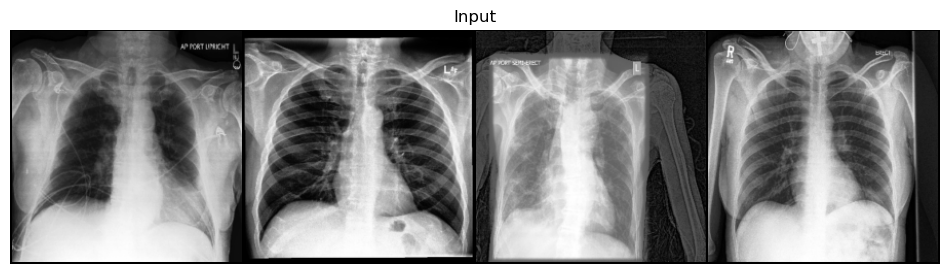

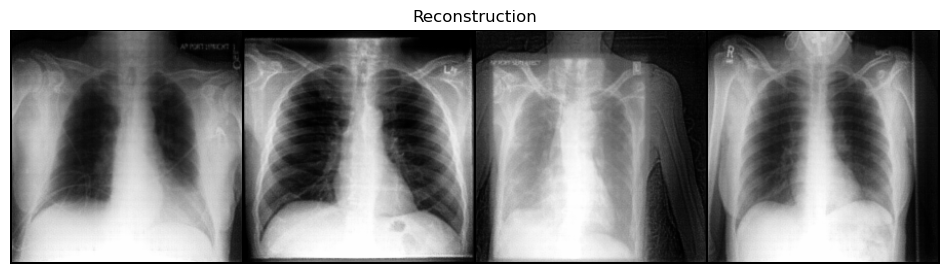

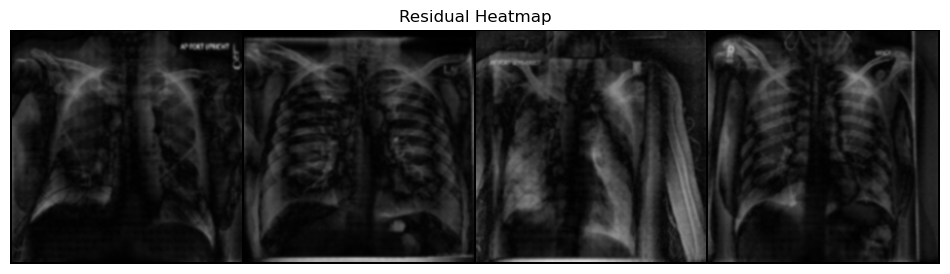

Done.


In [17]:
vae  = SmallVAE(in_ch=1, z_ch=cfg.LATENT_CH, beta_kl=cfg.VAE_BETA_KL)
unet = UNetLatent(z_ch=cfg.LATENT_CH, base=cfg.UNET_BASE)
ddpm = LatentDDPM(cfg.TIMESTEPS, cfg.BETA_START, cfg.BETA_END, device)

vae  = train_vae(vae, train_dl, cfg.VAE_EPOCHS, cfg.VAE_LR, cfg.OUTDIR)
unet = train_ldm(unet, vae.enc, train_dl, cfg.LDM_EPOCHS, cfg.LDM_LR, cfg.OUTDIR, ddpm)  # returns EMA’ed UNet

sample_and_save(vae, unet, valid_dl, ddpm, cfg.OUTDIR, n=cfg.SAMPLE_N)  # sampler should use v-pred
print("Done.")


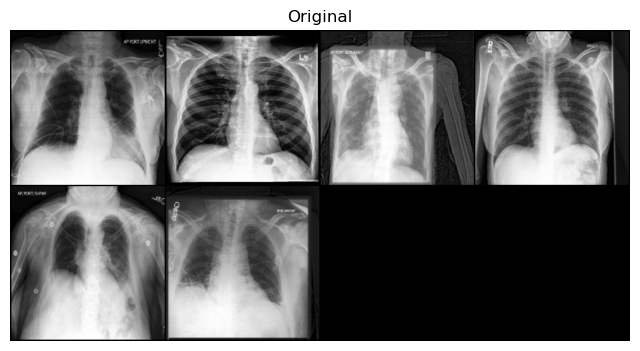

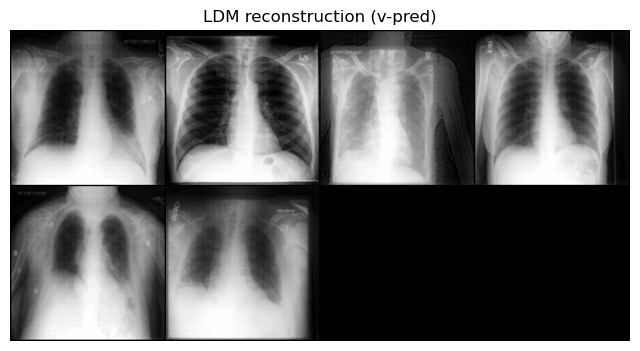

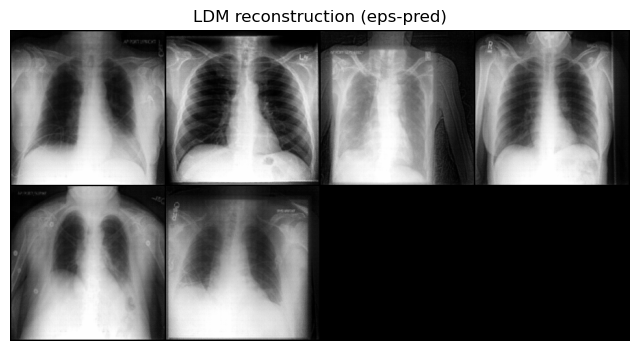

In [18]:
# --- Compare v-pred vs eps-pred sampling ---
batch = next(iter(valid_dl)).to(device)

x_ldm_v   = reconstruct_images(vae, unet, batch, ddpm, ddim_steps=cfg.DDIM_STEPS,
                               model_pred_type="v", sample_param="v")
x_ldm_eps = reconstruct_images(vae, unet, batch, ddpm, ddim_steps=cfg.DDIM_STEPS,
                               model_pred_type="v", sample_param="eps")


import torchvision.utils as vutils
import matplotlib.pyplot as plt

def show_grid(tensor, title):
    grid = vutils.make_grid(tensor.cpu(), nrow=4, normalize=True, value_range=(-1,1))
    plt.figure(figsize=(8,8))
    plt.title(title)
    plt.axis("off")
    plt.imshow(grid.permute(1,2,0))
    plt.show()

show_grid(batch, "Original")
show_grid(x_ldm_v, "LDM reconstruction (v-pred)")
show_grid(x_ldm_eps, "LDM reconstruction (eps-pred)")


In [19]:
# CELL A: CSV → labels (1 = abnormal, 0 = normal), keep frontal-only if column exists
import os, pandas as pd

def _norm_rel(p: str, root: str) -> str:
    p = str(p).replace("\\", "/")
    root = root.replace("\\", "/").rstrip("/")
    return p[p.find(root)+len(root)+1:] if root in p else p

def _tail3(p: str) -> str:
    p = str(p).replace("\\", "/")
    return "/".join(p.split("/")[-3:])  # patientXXXX/studyY/viewZ.jpg

valid_csv = cfg.VALID_CSV if os.path.isabs(cfg.VALID_CSV) else os.path.join(cfg.CHEXPERT_ROOT, cfg.VALID_CSV)
dfv = pd.read_csv(valid_csv)

# Filter to frontal if the column exists
if "Frontal/Lateral" in dfv.columns:
    dfv = dfv[dfv["Frontal/Lateral"].astype(str).str.lower().str.contains("frontal")]

# Label rule: 1 = abnormal (anything not "No Finding"), 0 = normal
dfv["label"] = (dfv.get("No Finding", 0).fillna(0) != 1).astype(int)

# Build normalized path keys
dfv["rel"]   = dfv["Path"].apply(lambda p: _norm_rel(p, cfg.CHEXPERT_ROOT))
dfv["tail3"] = dfv["rel"].apply(_tail3)

# Deduplicate on rel (safety)
dfv = dfv[["rel","tail3","label"]].drop_duplicates("rel")

print("CSV rows used (frontal-filtered if present):", len(dfv))


CSV rows used (frontal-filtered if present): 202


In [20]:
# --- Lung Mask v3 (canonical version, used by both scoring + vis) ---
import torch
import torch.nn.functional as F

@torch.no_grad()
def lung_mask_like(
    x,
    # shape & placement (scale-safe for any H×W; tuned at 192)
    rx=0.60, ry=0.78, xoff=0.26,
    top=0.07, bot=0.07,                 # 👈 NOTE: top / bot here
    # heart exclusion (slightly left & taller)
    heart_ax=0.82, heart_ay=0.60, heart_shift=0.04, heart_cut=0.34,
    # cleanups
    border=0.05, clavicle_cut=0.08,     # trim L/R border & top clavicles
    soften=2,                           # blur-before-threshold (>=1)
    close_ks=7, open_ks=5,              # morphology: closing then opening
    min_blob_px=220                     # remove tiny specks (approx area filter)
):
    """
    Returns bool mask [B,1,H,W] where True ≈ lung region (frontal CXR).
    Heuristics: twin ellipses ∪, minus heart, minus borders/clavicles, + morphology.
    """
    B, _, H, W = x.shape
    dev, dt = x.device, x.dtype

    # --- normalized grid with top/bottom crop applied in Y
    yy = torch.linspace(-1 + 2*top, 1 - 2*bot, H, device=dev, dtype=dt)
    xx = torch.linspace(-1, 1, W, device=dev, dtype=dt)
    Y, X = torch.meshgrid(yy, xx, indexing='ij')

    # --- twin ellipses (lungs)
    L = ((X + xoff)/rx)**2 + (Y/ry)**2 <= 1
    R = ((X - xoff)/rx)**2 + (Y/ry)**2 <= 1
    lung = (L | R)

    # --- heart exclusion (ellipse, shifted slightly left & up)
    heart = ((X + heart_shift)/(rx*heart_ax))**2 + ((Y + 0.10)/(ry*heart_ay))**2 <= heart_cut**2
    lung = lung & (~heart)

    # --- trim left/right borders (kill rails/markers) & clavicles (top)
    bx = int(border * W)
    ty = int(clavicle_cut * H)
    border_mask = torch.ones((H, W), dtype=torch.bool, device=dev)
    if bx > 0:
        border_mask[:, :bx]  = False
        border_mask[:, -bx:] = False
    if ty > 0:
        border_mask[:ty, :]  = False
    lung = lung & border_mask

    # --- to [B,1,H,W]
    lung = lung.float().view(1,1,H,W).expand(B,1,H,W)

    # --- soften (blur) then binarize (helps close gaps)
    if soften > 0:
        k = soften*2 + 1
        lung = (F.avg_pool2d(lung, k, 1, soften) > 0.5).float()

    # --- morphology: closing (fill small holes) then opening (remove spikes)
    def _morph(bin_f, ks, tau):
        return (F.avg_pool2d(bin_f, ks, 1, ks//2) >= tau).float()

    if close_ks and close_ks >= 3:
        lung = _morph(lung, close_ks, 0.45)  # closing approx
    if open_ks and open_ks >= 3:
        lung = _morph(lung, open_ks, 0.55)   # opening approx

    # --- approximate small-blob removal via local-area test
    k_area = 15 if min(H, W) <= 224 else 19
    area_avg = F.avg_pool2d(lung, k_area, 1, k_area//2)       # [B,1,H,W] in [0,1]
    px_in_win = area_avg * (k_area * k_area)
    keep = (px_in_win >= float(min_blob_px)).float()
    lung = (lung * keep) > 0.5

    return lung.bool()


In [21]:
# --- Cell 22B: Display-only heatmap (does NOT affect scoring) ---
import torch
import torch.nn.functional as F

@torch.no_grad()
def anomaly_vis_map(
    x, xh,
    rx=0.58, ry=0.72, top=0.10, bot=0.10,   # same mask shape as above
    fg_thresh=0.18, diag_frac=0.16,         # stricter FG + diaphragm cut
    smooth_thr=0.25, min_mask_px=800
):
    import torch, torch.nn.functional as F

    B, _, H, W = x.shape
    dev, dt = x.device, x.dtype

    # residual blend
    coarse = ((x - xh).abs() + 1.0) * 0.5
    # gentle multi-scale HF
    lap = torch.tensor([[0,-1,0],[-1,4,-1],[0,-1,0]], device=dev, dtype=dt).view(1,1,3,3)
    x01  = ((x  + 1)/2).clamp(0,1)
    xh01 = ((xh + 1)/2).clamp(0,1)
    hf1  = F.conv2d(x01,  lap, padding=1)
    hf2  = F.conv2d(xh01, lap, padding=1)
    hf   = ((hf1 - hf2).abs() + F.avg_pool2d((hf1 - hf2).abs(),3,1,1))/2
    hf   = (hf - hf.amin((2,3),True)) / (hf.amax((2,3),True) - hf.amin((2,3),True) + 1e-8)

    A = 0.7 * coarse + 0.3 * hf

    # mask = lungs ∩ foreground, minus diaphragm strip
    lung = lung_mask_like(x, rx=rx, ry=ry, top=top, bot=bot).bool()
    fg   = (((x + 1) * 0.5) > fg_thresh).bool()
    mask_bool = lung & fg
    cut = int(H * diag_frac)
    if cut > 0:
        mask_bool[:, :, -cut:, :] = False
    mask_bool = (F.avg_pool2d(mask_bool.float(), 3, 1, 1) > 0.6).bool()
    mask = mask_bool.float()
    small = mask_bool.flatten(1).sum(1) < min_mask_px

    g3 = torch.tensor([[1,2,1],[2,4,2],[1,2,1]], device=dev, dtype=dt).view(1,1,3,3)/16.0
    out = torch.zeros_like(A)

    for i in range(B):
        a, mm = A[i], mask_bool[i]
        if mm.any() and not bool(small[i].item()):
            vals = a[mm]; mu = vals.mean(); sd = vals.std().clamp_min(1e-6)
            a = (a - mu) / sd
            v = a[mm].view(-1)
            p1, p2 = torch.quantile(v, 0.80), torch.quantile(v, 0.995)
            a = (a - p1) / (p2 - p1 + 1e-6)

        a = (a.clamp(0,1) * mask[i])
        a = F.conv2d(a.unsqueeze(0), g3, padding=1).squeeze(0)
        a2 = F.avg_pool2d(a, 3, 1, 1)
        a  = torch.where(a2 > smooth_thr, a2, torch.zeros_like(a2))

        if mm.any() and not bool(small[i].item()):
            lo, hi = a[mm].min(), a[mm].max()
            a = (a - lo) / (hi - lo + 1e-6)

        out[i] = a

    mmax = out.amax(dim=(2,3), keepdim=True).clamp_min(1e-8)
    return (out / mmax).clamp(0,1)


# --- Cell 22C: Overlay helpers (for visualization only) ---
import matplotlib.pyplot as plt
import numpy as np

def _to_numpy01(t):
    """[-1,1] tensor [B,1,H,W] -> [B,H,W] numpy in [0,1]."""
    t01 = ((t + 1) * 0.5).clamp(0, 1)
    return t01.squeeze(1).detach().cpu().numpy()

def show_overlay_grid(x, heat, cols=4, alpha=0.45, cmap='inferno', title="Overlay"):
    """
    Show input images with heatmap overlays.
      x:    [B,1,H,W] in [-1,1]
      heat: [B,1,H,W] in [0,1]
    """
    x_np = _to_numpy01(x)
    heat_np = heat.squeeze(1).detach().cpu().numpy()
    B = x_np.shape[0]
    rows = int(np.ceil(B / cols))
    plt.figure(figsize=(3.2 * cols, 3.5 * rows))
    for i in range(B):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(x_np[i], cmap='gray', vmin=0, vmax=1)
        plt.imshow(heat_np[i], cmap=cmap, alpha=alpha, vmin=0, vmax=1)
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [22]:
# CELL B: align labels to valid_ds order via exact 'rel', with 'tail3' fallback
import numpy as np, pandas as pd

# valid_ds must expose absolute file paths in .paths
ds_paths_abs = [str(p) for p in getattr(valid_ds, "paths", [])]
if not ds_paths_abs:
    raise RuntimeError("valid_ds.paths is empty; ensure your dataset exposes file paths.")

df_ds = pd.DataFrame({"abs": ds_paths_abs})
df_ds["rel"]   = df_ds["abs"].apply(lambda p: _norm_rel(p, cfg.CHEXPERT_ROOT))
df_ds["tail3"] = df_ds["rel"].apply(_tail3)

# 1) exact join on rel
m = df_ds.merge(dfv[["rel","label"]], on="rel", how="left")

# 2) fill any missing labels by tail3 key
missing = m["label"].isna()
if missing.any():
    m2 = df_ds[missing].merge(dfv[["tail3","label"]], on="tail3", how="left")
    m.loc[missing, "label"] = m2["label"].values

keep_mask  = ~m["label"].isna()
labels_all = m["label"].fillna(0).astype(int).to_numpy()

print(f"Aligned labels: kept {int(keep_mask.sum())}/{len(keep_mask)} with labels")
pos_rate = labels_all[keep_mask].mean() if keep_mask.any() else 0.0
print(f"Positive (abnormal) rate among kept = {pos_rate:.3f}")


Aligned labels: kept 202/202 with labels
Positive (abnormal) rate among kept = 0.871


In [23]:
# --- Cell: score_batch_all (multi-scale HF + masked SSIM + weighted combo) ---
import torch
import numpy as np
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim

# Hi-frequency residual heat — only define if missing
if "hi_freq_heat" not in globals():
    @torch.no_grad()
    def hi_freq_heat(x, xh):
        k = torch.tensor([[0,-1,0],[-1,4,-1],[0,-1,0]], device=x.device, dtype=x.dtype).view(1,1,3,3)
        k = k / k.abs().sum()
        x01  = (x  + 1)/2
        xh01 = (xh + 1)/2
        hx   = F.conv2d(x01,  k, padding=1)
        hxh  = F.conv2d(xh01, k, padding=1)
        res_hf = (hx - hxh).abs()
        B = res_hf.size(0)
        res_hf = (res_hf - res_hf.view(B,-1).min(1)[0].view(B,1,1,1)) / \
                 (res_hf.view(B,-1).max(1)[0].view(B,1,1,1) - res_hf.view(B,-1).min(1)[0].view(B,1,1,1) + 1e-8)
        return res_hf.clamp(0,1)

assert callable(hi_freq_heat) and callable(lung_mask_like)
print("Rescue helpers ready: hi_freq_heat, lung_mask_like")

@torch.no_grad()
def score_batch_all(x, xh, p=95, fg_thresh=0.18, diag_frac=0.16, min_mask_px=800):
    """
    Returns dict of numpy arrays: 'lung_p95', 'lung_hf_p95', 'lung_invssim', 'combo'
    Inputs x, xh in [-1,1], [B,1,H,W].
    """
    import torch
    import torch.nn.functional as F
    import numpy as np
    from skimage.metrics import structural_similarity as ssim

    B, _, H, W = x.shape
    dev = x.device

    # masks (lung ∩ bright FG) with diaphragm suppression
    lung = lung_mask_like(x).bool()
    fg   = (((x + 1) * 0.5) > fg_thresh).bool()
    mask = lung & fg
    cut  = int(H * diag_frac)
    if cut > 0:
        mask[:, :, -cut:, :] = False

    # despeckle tiny islands
    mask = (F.avg_pool2d(mask.float(), 3, 1, 1) > 0.6).bool()

    # guard: if mask too small, fall back to lung only
    small = mask.flatten(1).sum(1) < min_mask_px
    if small.any():
        mask[small] = lung[small]

    # coarse residual in [0,1]
    res   = (x - xh).abs()
    res01 = ((res + 1.0) * 0.5).clamp(0, 1)

    # multi-scale HF residual
    lap = torch.tensor([[0,-1,0],[-1,4,-1],[0,-1,0]], device=dev, dtype=torch.float32).view(1,1,3,3)
    x01  = ((x  + 1)/2).clamp(0,1)
    xh01 = ((xh + 1)/2).clamp(0,1)
    hf1  = F.conv2d(x01,  lap, padding=1)
    hf2  = F.conv2d(xh01, lap, padding=1)
    res_hf1 = (hf1 - hf2).abs()
    res_hf2 = F.avg_pool2d(res_hf1, 3, 1, 1)
    res_hf  = (res_hf1 + res_hf2) / 2.0
    res_hf  = (res_hf - res_hf.amin(dim=(2,3), keepdim=True)) / \
              (res_hf.amax(dim=(2,3), keepdim=True) - res_hf.amin(dim=(2,3), keepdim=True) + 1e-8)

    # p95 inside mask
    lung_p95, lung_hf_p95 = [], []
    for i in range(B):
        m = mask[i]
        if m.sum() == 0:
            lung_p95.append(torch.tensor(0., device=dev))
            lung_hf_p95.append(torch.tensor(0., device=dev))
            continue
        lung_p95.append(res01[i][m].quantile(p/100))
        lung_hf_p95.append(res_hf[i][m].quantile(p/100))
    lung_p95    = torch.stack(lung_p95).float()
    lung_hf_p95 = torch.stack(lung_hf_p95).float()

    # masked SSIM on lung bbox
    x_np   = x01.squeeze(1).cpu().numpy()
    xh_np  = xh01.squeeze(1).cpu().numpy()
    lung_np= lung.squeeze(1).cpu().numpy()
    inv_ssim = []
    for i in range(B):
        yy, xx = np.where(lung_np[i])
        if yy.size == 0:
            inv_ssim.append(0.0); continue
        y0,y1 = yy.min(), yy.max(); x0,x1 = xx.min(), xx.max()
        inv_ssim.append(1.0 - ssim(x_np[i, y0:y1+1, x0:x1+1],
                                   xh_np[i, y0:y1+1, x0:x1+1],
                                   data_range=1.0))
    inv_ssim = torch.tensor(inv_ssim, device=dev).float()

    # weighted combo (keep for baseline; you can still do LogReg later)
    combo = 0.30 * lung_p95 + 0.50 * lung_hf_p95 + 0.20 * inv_ssim

    return {
        "lung_p95":      lung_p95.cpu().numpy(),
        "lung_hf_p95":   lung_hf_p95.cpu().numpy(),
        "lung_invssim":  inv_ssim.cpu().numpy(),
        "combo":         combo.cpu().numpy(),
    }



Rescue helpers ready: hi_freq_heat, lung_mask_like


In [24]:
import numpy as np
import torch

def score_ensemble_combo(x, reps=[(120,0.0,0.6), (180,0.0,0.8), (120,0.2,0.7)],
                         use_flip=True, p=95, default_strength=0.7):
    import numpy as np, torch
    scores = []
    xf = torch.flip(x, dims=[3]) if use_flip else None
    for rep in reps:
        if len(rep) == 2:
            steps, eta = rep; strength = default_strength
        else:
            steps, eta, strength = rep
        xh  = reconstruct_images(vae, unet, x,  ddpm, ddim_steps=steps, eta=eta,
                                 model_pred_type="v", strength=strength)
        s   = score_batch_all(x,  xh,  p=p)["combo"]
        scores.append(s)
        if use_flip:
            xhf = reconstruct_images(vae, unet, xf, ddpm, ddim_steps=steps, eta=eta,
                                     model_pred_type="v", strength=strength)
            sf  = score_batch_all(xf, xhf, p=p)["combo"]
            scores.append(sf)
    return np.mean(np.stack(scores, 0), 0)


In [25]:
# === CELL C (modified for ensemble Combo) ===
import numpy as np
from tqdm import tqdm

all_coarse, all_hf, all_inv, all_combo = [], [], [], []

with torch.no_grad():
    for xb in tqdm(valid_dl, desc="Scoring valid set"):
        xb = xb.to(device, non_blocking=True)

        xh_single = reconstruct_images(
            vae, unet, xb, ddpm,
            ddim_steps=cfg.DDIM_STEPS,
            model_pred_type="v",
            sample_param="v"
        )
        s_single = score_batch_all(xb, xh_single, p=95)

        all_coarse.append(s_single["lung_p95"])
        all_hf.append(s_single["lung_hf_p95"])
        all_inv.append(s_single["lung_invssim"])

        s_combo = score_ensemble_combo(
            xb,
            reps=[(100,0.0,0.6), (150,0.0,0.8), (100,0.2,0.7)],
            use_flip=True,
            p=95
        )
        all_combo.append(s_combo)


s_coarse = np.concatenate(all_coarse)
s_hf     = np.concatenate(all_hf)
s_inv    = np.concatenate(all_inv)
s_combo  = np.concatenate(all_combo)

metrics_raw = {
    "Coarse (p95)": s_coarse,
    "HF (p95)":     s_hf,
    "1-SSIM":       s_inv,
    "Combo":        s_combo,   # << ensemble combo
}

print({k: v.shape for k, v in metrics_raw.items()})


Scoring valid set: 100%|██████████| 34/34 [03:29<00:00,  6.16s/it]

{'Coarse (p95)': (202,), 'HF (p95)': (202,), '1-SSIM': (202,), 'Combo': (202,)}


(Rebuilt baseline Combo AUC = 0.530)
Logistic Regression Combo AUC = 0.730


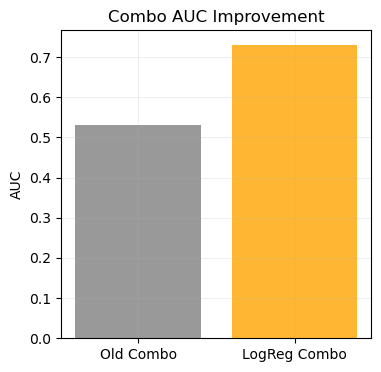

In [26]:
# --- Cell: Auto-tune combo weights by label correlation (with LogReg) ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Make sure we have a valid base AUC (rebuild if user didn't run Cell D)
if "best_auc_val" not in locals():
    from sklearn.metrics import roc_curve
    labels_vec = labels_all[keep_mask].astype(int)
    sc = metrics_raw["Combo"][keep_mask]
    auc_raw = roc_auc_score(labels_vec, sc)
    auc_flip = roc_auc_score(labels_vec, -sc)
    best_auc_val = max(auc_raw, auc_flip)
    print(f"(Rebuilt baseline Combo AUC = {best_auc_val:.3f})")

# --- prepare features ---
X = np.stack([
    metrics_raw["Coarse (p95)"][keep_mask],
    metrics_raw["HF (p95)"][keep_mask],
    metrics_raw["1-SSIM"][keep_mask]
], axis=1)
y = labels_all[keep_mask].astype(int)

# --- logistic regression combo ---
scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)
logit = LogisticRegression(max_iter=200, solver='lbfgs').fit(Xs, y)
proba = logit.predict_proba(Xs)[:, 1]
auc_tuned = roc_auc_score(y, proba)
print(f"Logistic Regression Combo AUC = {auc_tuned:.3f}")

# --- compare visually with OLD Combo (from metrics_raw) ---
old_combo = metrics_raw["Combo"][keep_mask]
auc_old   = roc_auc_score(y, old_combo)
plt.figure(figsize=(4,4))
plt.bar(["Old Combo","LogReg Combo"], [auc_old, auc_tuned],
        color=["gray","orange"], alpha=0.8)
plt.title("Combo AUC Improvement")
plt.ylabel("AUC")
plt.grid(alpha=0.2)
plt.show()

# add tuned scores as another metric candidate
metrics_raw["LogReg Combo"] = np.zeros_like(labels_all, dtype=float)
metrics_raw["LogReg Combo"][keep_mask] = proba




AUCs (auto-pick sign so '1 = abnormal' gives higher scores):
Coarse (p95) AUC = 0.622 (flipped)
HF (p95)     AUC = 0.602 (flipped)
1-SSIM       AUC = 0.721 (flipped)
Combo        AUC = 0.530
LogReg Combo AUC = 0.730

Selected metric: LogReg Combo | AUC=0.730
Normal mean=0.7996  Abnormal mean=0.8819


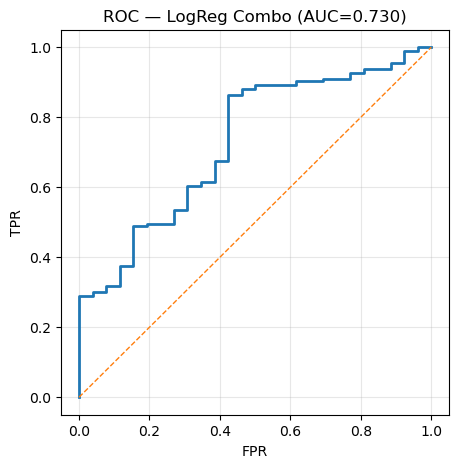

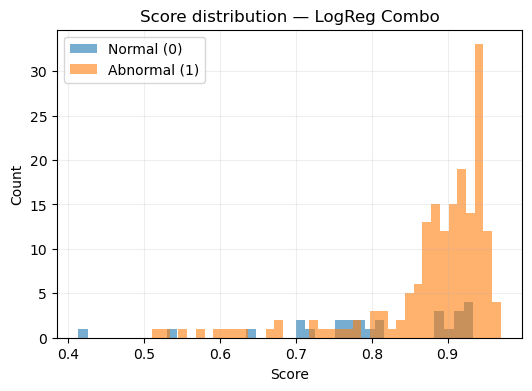

In [27]:
# CELL D: evaluate AUCs; automatically flip sign if needed so that higher = more abnormal
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

labels_vec = labels_all[keep_mask].astype(int)

def best_auc(sc, y):
    auc_raw  = roc_auc_score(y, sc)
    auc_flip = roc_auc_score(y, -sc)
    return (auc_flip, True) if auc_flip > auc_raw else (auc_raw, False)

print("\nAUCs (auto-pick sign so '1 = abnormal' gives higher scores):")
best_name, best_auc_val, best_scores = None, -1.0, None

for name, arr in metrics_raw.items():
    sc = arr[keep_mask]
    auc_val, flipped = best_auc(sc, labels_vec)
    tag = " (flipped)" if flipped else ""
    print(f"{name:12s} AUC = {auc_val:.3f}{tag}")
    if auc_val > best_auc_val:
        best_name, best_auc_val = name, auc_val
        best_scores = (-sc if flipped else sc)

# quick sanity: means by class
neg_mean = best_scores[labels_vec==0].mean() if (labels_vec==0).any() else np.nan
pos_mean = best_scores[labels_vec==1].mean() if (labels_vec==1).any() else np.nan
print(f"\nSelected metric: {best_name} | AUC={best_auc_val:.3f}")
print(f"Normal mean={neg_mean:.4f}  Abnormal mean={pos_mean:.4f}")

# plot ROC for the selected metric (correct orientation)
fpr, tpr, _ = roc_curve(labels_vec, best_scores)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, lw=2)
plt.plot([0,1],[0,1],'--', lw=1)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.grid(alpha=.3)
plt.title(f"ROC — {best_name} (AUC={best_auc_val:.3f})")
plt.show()

# optional: histogram
plt.figure(figsize=(6,4))
plt.hist(best_scores[labels_vec==0], bins=40, alpha=0.6, label="Normal (0)")
plt.hist(best_scores[labels_vec==1], bins=40, alpha=0.6, label="Abnormal (1)")
plt.legend(); plt.grid(alpha=.2)
plt.title(f"Score distribution — {best_name}")
plt.xlabel("Score"); plt.ylabel("Count")
plt.show()


In [28]:
from sklearn.metrics import confusion_matrix

print("\n=== Threshold Search ===")

best_f1 = -1
best_thr = None
best_metrics = None

for t in np.linspace(min(best_scores), max(best_scores), 200):
    y_hat = (best_scores >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(labels_vec, y_hat).ravel()
    
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thr = t
        best_metrics = (prec, rec, f1)

print(f"Best Threshold = {best_thr:.5f}")
print(f"Precision = {best_metrics[0]:.3f}")
print(f"Recall    = {best_metrics[1]:.3f}")
print(f"F1-score  = {best_metrics[2]:.3f}")



=== Threshold Search ===
Best Threshold = 0.41634
Precision = 0.876
Recall    = 1.000
F1-score  = 0.934


In [29]:
# Persist the best threshold found in the search
BEST_THR = float(best_thr)  # best_thr variable came from the search cell
print("Using BEST_THR =", BEST_THR)


Using BEST_THR = 0.41633722460723166


In [30]:
# CELL 26 — evaluate at fixed BEST_THR instead of Youden J
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix, auc, precision_recall_fscore_support

y = labels_all[keep_mask].astype(int)

# keep the ROC (for plotting only)
fpr, tpr, thr = roc_curve(y, best_scores)
auc_val = auc(fpr, tpr)

# >>> use your chosen threshold <<<
y_hat = (best_scores >= BEST_THR).astype(int)

cm = confusion_matrix(y, y_hat)
tn, fp, fn, tp = cm.ravel()

prec = tp / (tp + fp + 1e-9)
rec  = tp / (tp + fn + 1e-9)
f1   = 2 * prec * rec / (prec + rec + 1e-9)

print(f"Selected metric: {best_name} | AUC={auc_val:.3f}")
print(f"Threshold (Fixed): {BEST_THR:.5f}")
print(f"Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
print("Confusion Matrix [ [TN FP]; [FN TP] ]:")
print(cm)


Selected metric: LogReg Combo | AUC=0.730
Threshold (Fixed): 0.41634
Precision: 0.876 | Recall: 1.000 | F1: 0.934
Confusion Matrix [ [TN FP]; [FN TP] ]:
[[  1  25]
 [  0 176]]


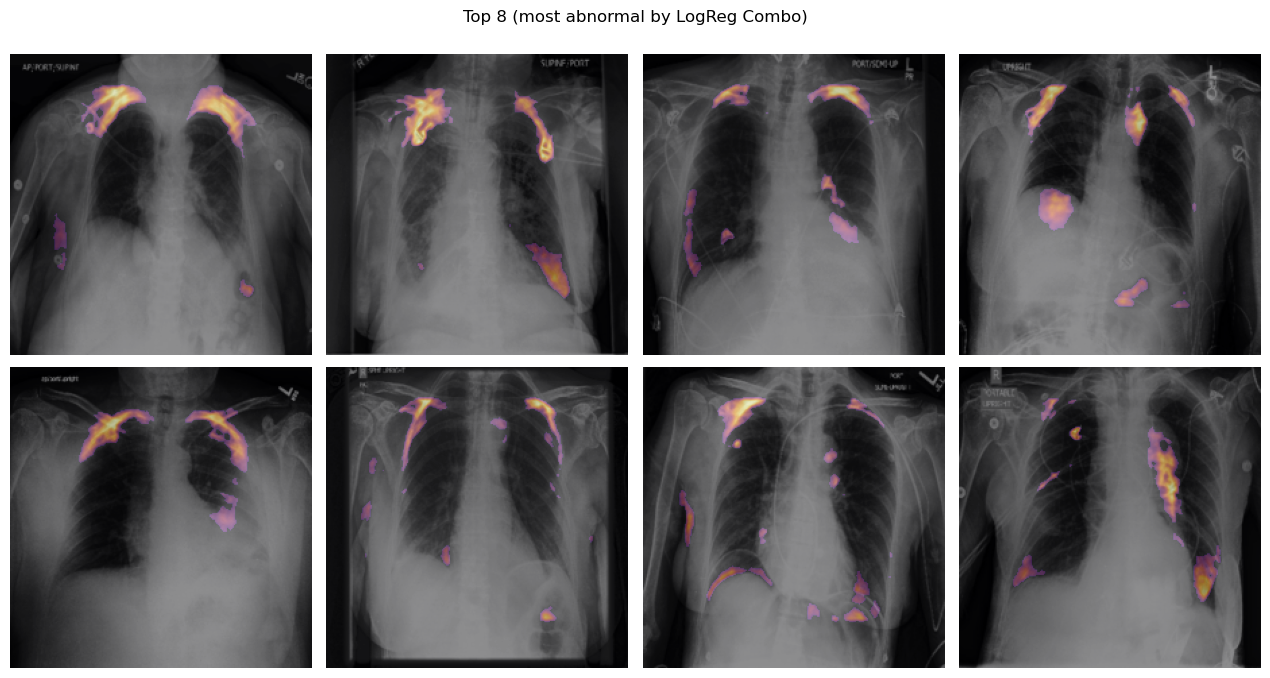

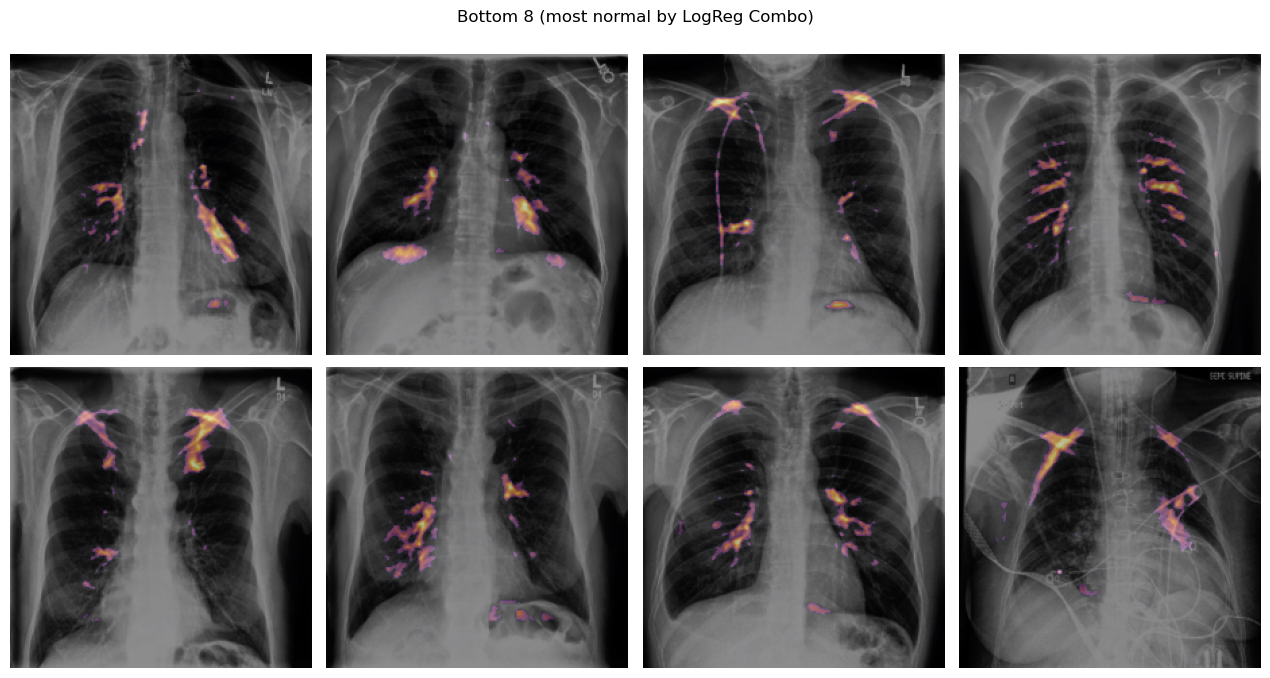

In [31]:
# CELL F: show overlays for top-K and bottom-K by the selected metric
import torch

K = 8  # how many to show

# indices in dataset order for kept items
idx_kept = np.nonzero(keep_mask.to_numpy() if hasattr(keep_mask, "to_numpy") else keep_mask)[0]

# sort kept indices by score
order = np.argsort(-best_scores)  # descending = most abnormal
top_idx   = idx_kept[order[:K]]
bottom_idx= idx_kept[order[-K:]]

def collect_batch(indices):
    """Re-iterate valid_dl and return (x, xh) stacked for the given dataset indices."""
    want = set(indices.tolist() if hasattr(indices, "tolist") else list(indices))
    xs, xhs = [], []
    base = 0
    with torch.no_grad():
        for xb in valid_dl:
            b = xb.size(0)
            sel = [i for i in range(b) if (base + i) in want]
            if sel:
                xb = xb.to(device, non_blocking=True)
                xh = reconstruct_images(
                    vae, unet, xb, ddpm,
                    ddim_steps=cfg.DDIM_STEPS,
                    model_pred_type="v",
                    sample_param="v"
                )
                xs.append(xb[sel].cpu())
                xhs.append(xh[sel].cpu())
            base += b
    x  = torch.cat(xs,  dim=0)
    xh = torch.cat(xhs, dim=0)
    return x.to(device), xh.to(device)

# Top-K most abnormal
xb_top, xh_top = collect_batch(top_idx)
vis_top = anomaly_vis_map(xb_top, xh_top)
show_overlay_grid(xb_top, vis_top, cols=4, alpha=0.45, cmap='inferno',
                  title=f"Top {K} (most abnormal by {best_name})")

# Bottom-K most normal
xb_bot, xh_bot = collect_batch(bottom_idx)
vis_bot = anomaly_vis_map(xb_bot, xh_bot)
show_overlay_grid(xb_bot, vis_bot, cols=4, alpha=0.45, cmap='inferno',
                  title=f"Bottom {K} (most normal by {best_name})")
